## 6000 TASK 1

In [ ]:
!git clone https://github.com/karpathy/nanoGPT.git
%cd nanoGPT

fatal: destination path 'nanoGPT' already exists and is not an empty directory.
/content/nanoGPT


In [ ]:
!python3 data/shakespeare_char/prepare.py

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [ ]:
!nvidia-smi
!pip list | grep -E "torch|numpy|transformers"

Tue Mar 10 22:55:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   69C    P8             20W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import numpy as np
import math

# From train_shakespeare_char.py
batch_size = 64
block_size = 256

# Read the generated training data to get the exact token count
train_data = np.memmap('data/shakespeare_char/train.bin', dtype=np.uint16, mode='r')
num_train_tokens = len(train_data)

# Calculate steps_per_epoch using the required formula
steps_per_epoch = math.floor(num_train_tokens / (batch_size * block_size))

# Map the checkpoints
step_5 = 5 * steps_per_epoch
step_50 = 50 * steps_per_epoch
step_500 = 500 * steps_per_epoch

print(f"Total training tokens: {num_train_tokens:,}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Checkpoint 1 (5 epochs): {step_5} steps")
print(f"Checkpoint 2 (50 epochs): {step_50} steps")
print(f"Checkpoint 3 (500 epochs): {step_500} steps")

Total training tokens: 1,003,854
Steps per epoch: 61
Checkpoint 1 (5 epochs): 305 steps
Checkpoint 2 (50 epochs): 3050 steps
Checkpoint 3 (500 epochs): 30500 steps


In [ ]:
print(train_data)

[18 47 56 ... 43 56 43]


In [ ]:
# Train from scratch to 5 epochs using our calculated steps
!python train.py config/train_shakespeare_char.py \
    --init_from='scratch' \
    --max_iters={step_5} \
    --lr_decay_iters={step_500} \
    --eval_interval={steps_per_epoch} \
    --always_save_checkpoint=True | tee -a train_log.txt

# Generate the 5-Epoch Sample
print("\n========== 5 EPOCH SAMPLE ==========")
!python sample.py --out_dir=out-shakespeare-char --start="ROMEO" --num_samples=1 --max_new_tokens=500

/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate 

In [ ]:
# Resume training and push to 50 epochs
!python train.py config/train_shakespeare_char.py \
    --init_from='resume' \
    --max_iters={step_50} \
    --lr_decay_iters={step_500} \
    --eval_interval={steps_per_epoch} \
    --always_save_checkpoint=True | tee -a train_log.txt

# Generate the 50-Epoch Sample
print("\n========== 50 EPOCH SAMPLE ==========")
!python sample.py --out_dir=out-shakespeare-char --start="ROMEO" --num_samples=1 --max_new_tokens=500

/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate 

In [ ]:
# Resume training and push to 500 epochs
!python train.py config/train_shakespeare_char.py \
    --init_from='resume' \
    --max_iters={step_500} \
    --lr_decay_iters={step_500} \
    --eval_interval={steps_per_epoch} \
    --always_save_checkpoint=True | tee -a train_log.txt

# Generate the 500-Epoch Sample
print("\n========== 500 EPOCH SAMPLE ==========")
!python sample.py --out_dir=out-shakespeare-char --start="ROMEO" --num_samples=1 --max_new_tokens=500

/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate 

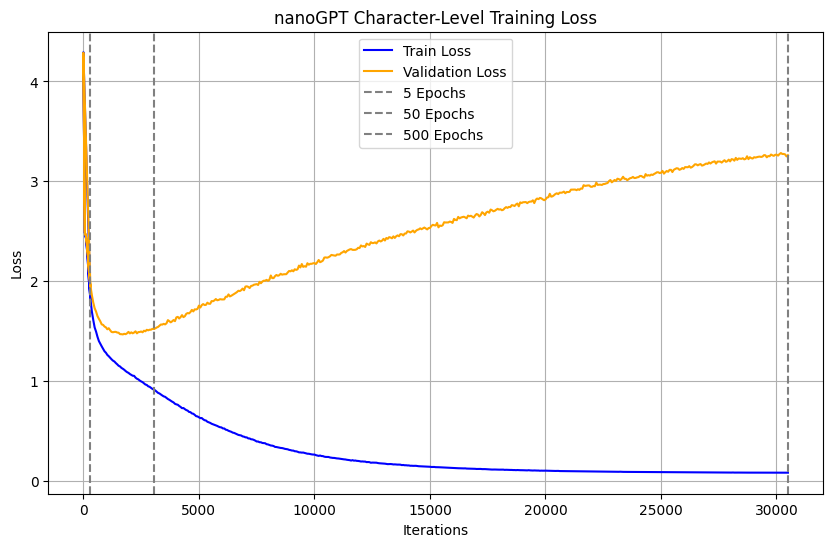

In [ ]:
import matplotlib.pyplot as plt
import re

iters, train_loss, val_loss = [], [], []

# Parse the log file generated by our tee commands
with open("train_log.txt", "r") as f:
    for line in f:
        matched = re.search(r"step (\d+): train loss (\d+\.\d+), val loss (\d+\.\d+)", line)
        if matched:
            iters.append(int(matched.group(1)))
            train_loss.append(float(matched.group(2)))
            val_loss.append(float(matched.group(3)))

# Plot the curves
plt.figure(figsize=(10, 6))
plt.plot(iters, train_loss, label="Train Loss", color="blue")
plt.plot(iters, val_loss, label="Validation Loss", color="orange")
plt.axvline(x=305, color='gray', linestyle='--', label='5 Epochs')
plt.axvline(x=3050, color='gray', linestyle='--', label='50 Epochs')
plt.axvline(x=30500, color='gray', linestyle='--', label='500 Epochs')

plt.title("nanoGPT Character-Level Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()